<a href="https://colab.research.google.com/github/shailaja-ds/shailaja-ds-Sales-Data-Analysis-Prediction/blob/main/Sales_Data_Analysis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = {
    "order_id": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "product": [
        "Laptop", "Phone", "Headphones", "Tablet", "Laptop",
        "Phone", "Smartwatch", "Tablet", "Headphones", "Phone"
    ],
    "category": [
        "Electronics", "Electronics", "Accessories", "Electronics",
        "Electronics", "Electronics", "Accessories", "Electronics",
        "Accessories", "Electronics"
    ],
    "quantity": [2, 3, 5, 2, 1, 4, 3, 2, 6, 5],
    "price": [60000, 25000, 3000, 20000, 65000, 22000, 8000, 18000, 2500, 24000],
    "sales": [120000, 75000, 15000, 40000, 65000, 88000, 24000, 36000, 15000, 120000]
}

df = pd.DataFrame(data)

print("Sales dataset created successfully!")
df

Sales dataset created successfully!


,order_id,product,category,quantity,price,sales
0,1001,Laptop,Electronics,2,60000,120000
1,1002,Phone,Electronics,3,25000,75000
2,1003,Headphones,Accessories,5,3000,15000
3,1004,Tablet,Electronics,2,20000,40000
4,1005,Laptop,Electronics,1,65000,65000
5,1006,Phone,Electronics,4,22000,88000
6,1007,Smartwatch,Accessories,3,8000,24000
7,1008,Tablet,Electronics,2,18000,36000
8,1009,Headphones,Accessories,6,2500,15000
9,1010,Phone,Electronics,5,24000,120000


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(10, 6)

Column Names:
Index(['order_id', 'product', 'category', 'quantity', 'price', 'sales'], dtype='object')

Missing Values:
order_id    0
product     0
category    0
quantity    0
price       0
sales       0
dtype: int64

Duplicate Rows:
0


In [ ]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,order_id,quantity,price,sales
count,10.00000,10.000000,10.000000,10.000000
mean,1005.50000,3.300000,24750.000000,59800.000000
std,3.02765,1.636392,21570.620452,40215.530444
min,1001.00000,1.000000,2500.000000,15000.000000
25%,1003.25000,2.000000,10500.000000,27000.000000
50%,1005.50000,3.000000,21000.000000,52500.000000
75%,1007.75000,4.750000,24750.000000,84750.000000
max,1010.00000,6.000000,65000.000000,120000.000000


In [ ]:
product_sales = df.groupby("product")["sales"].sum().sort_values(ascending=False)

print("Total Sales by Product:")
print(product_sales)

Total Sales by Product:
product
Phone         283000
Laptop        185000
Tablet         76000
Headphones     30000
Smartwatch     24000
Name: sales, dtype: int64


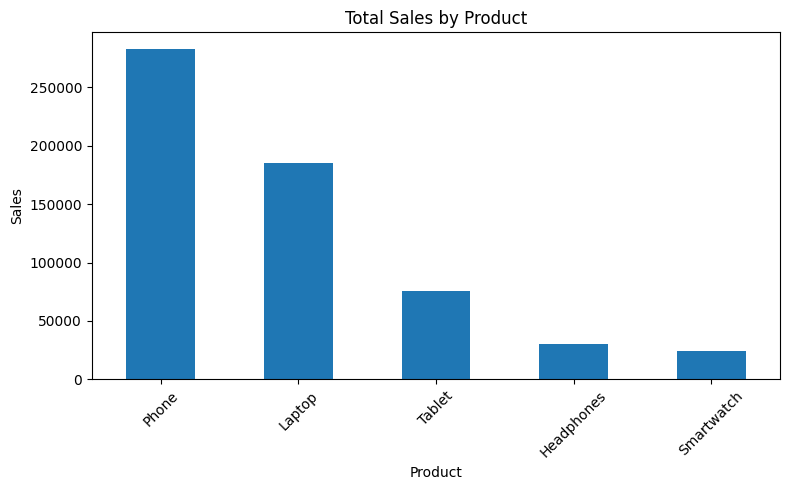

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)

print("Total Sales by Category:")
print(category_sales)

Total Sales by Category:
category
Electronics    544000
Accessories     54000
Name: sales, dtype: int64


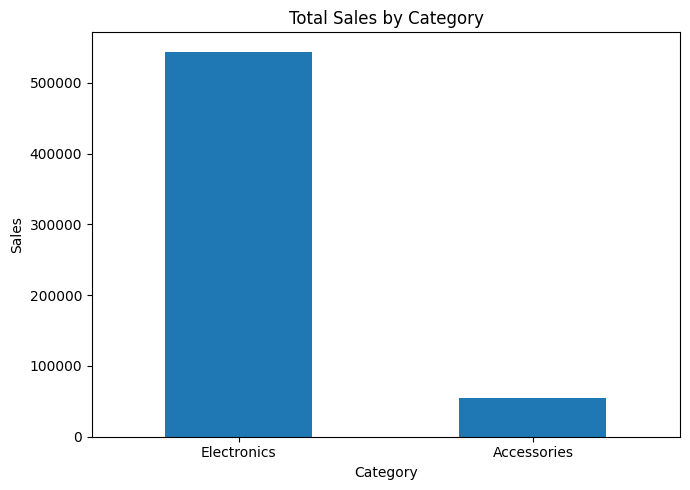

In [ ]:
plt.figure(figsize=(7, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

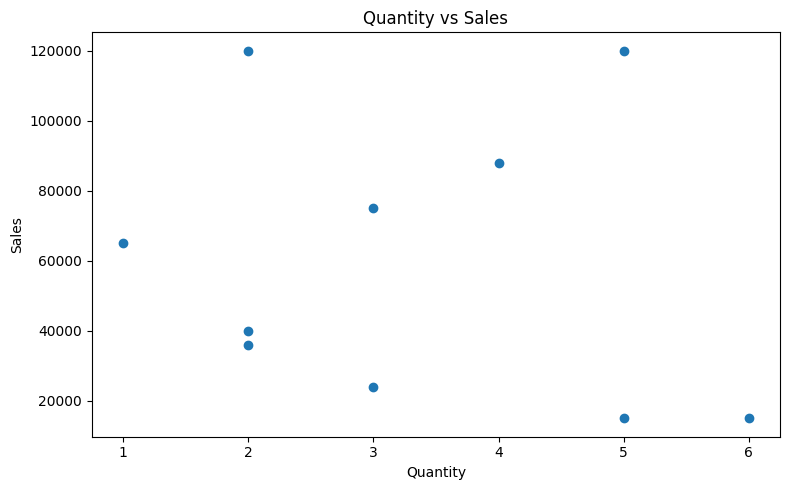

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["quantity"], df["sales"])

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [ ]:
avg_sales_product = df.groupby("product")["sales"].mean().sort_values(ascending=False)

print("Average Sales by Product:")
print(avg_sales_product)

Average Sales by Product:
product
Phone         94333.333333
Laptop        92500.000000
Tablet        38000.000000
Smartwatch    24000.000000
Headphones    15000.000000
Name: sales, dtype: float64


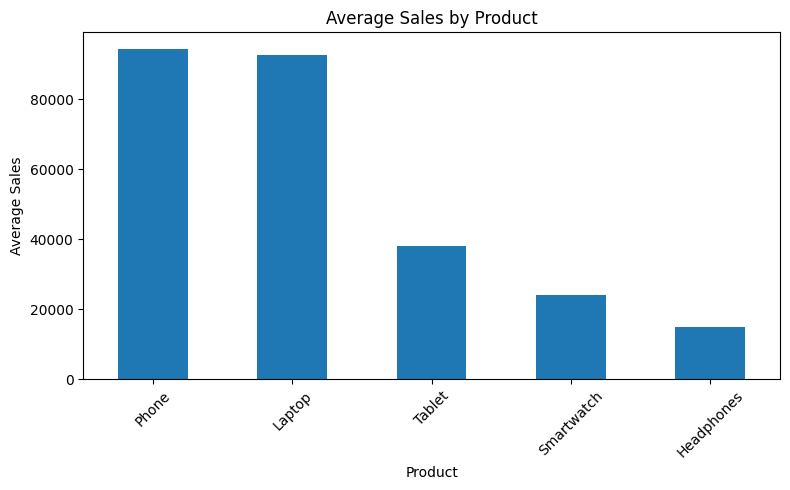

In [ ]:
plt.figure(figsize=(8, 5))

avg_sales_product.plot(kind="bar")

plt.title("Average Sales by Product")
plt.xlabel("Product")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
best_product = product_sales.idxmax()
best_sales = product_sales.max()

print("Best-Selling Product:", best_product)
print("Total Sales:", best_sales)

Best-Selling Product: Phone
Total Sales: 283000


In [ ]:
total_sales = df["sales"].sum()
total_quantity = df["quantity"].sum()
average_sales = df["sales"].mean()

print("Overall Sales Summary")
print("---------------------")
print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Average Sales per Order:", average_sales)

Overall Sales Summary
---------------------
Total Sales: 598000
Total Quantity Sold: 33
Average Sales per Order: 59800.0


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["quantity", "price"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8, 2)
Testing data shape: (2, 2)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

Actual Sales:
[15000 75000]

Predicted Sales:
[76314.44241316 58632.54113346]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Evaluation
-----------------
MAE: 38840.95063985376
MSE: 2013677279.0925424
R² Score: -1.2374191989917138


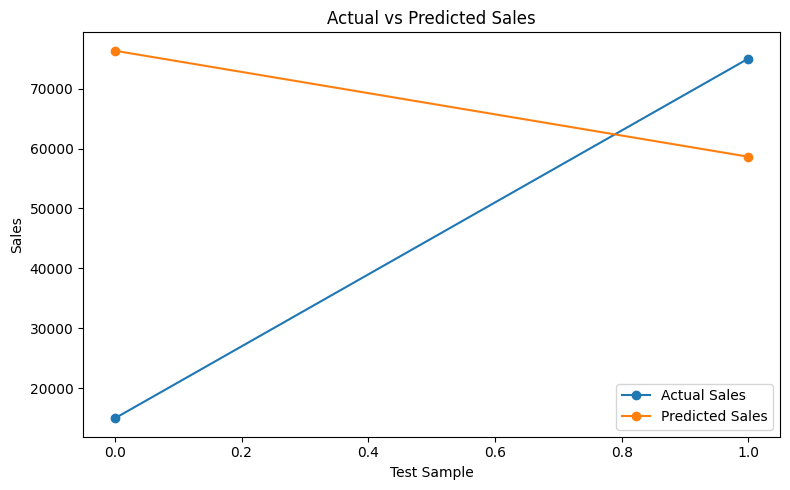

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, marker="o", label="Actual Sales")
plt.plot(y_pred, marker="o", label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Sample")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
new_order = pd.DataFrame({
    "quantity": [4],
    "price": [30000]
})

predicted_sales = model.predict(new_order)

print("Predicted Sales for New Order:", predicted_sales[0])

Predicted Sales for New Order: 88863.802559415


In [1]:
df.to_csv("dataset.csv", index=False)

print("Sales project dataset.csv created successfully!")

NameError: name 'df' is not defined

In [2]:
import pandas as pd

data = {
    "order_id": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "product": [
        "Laptop", "Phone", "Headphones", "Tablet", "Laptop",
        "Phone", "Smartwatch", "Tablet", "Headphones", "Phone"
    ],
    "category": [
        "Electronics", "Electronics", "Accessories", "Electronics",
        "Electronics", "Electronics", "Accessories", "Electronics",
        "Accessories", "Electronics"
    ],
    "quantity": [2, 3, 5, 2, 1, 4, 3, 2, 6, 5],
    "price": [60000, 25000, 3000, 20000, 65000, 22000, 8000, 18000, 2500, 24000],
    "sales": [120000, 75000, 15000, 40000, 65000, 88000, 24000, 36000, 15000, 120000]
}

df = pd.DataFrame(data)

print("Sales dataset recreated successfully!")
df

Sales dataset recreated successfully!


,order_id,product,category,quantity,price,sales
0,1001,Laptop,Electronics,2,60000,120000
1,1002,Phone,Electronics,3,25000,75000
2,1003,Headphones,Accessories,5,3000,15000
3,1004,Tablet,Electronics,2,20000,40000
4,1005,Laptop,Electronics,1,65000,65000
5,1006,Phone,Electronics,4,22000,88000
6,1007,Smartwatch,Accessories,3,8000,24000
7,1008,Tablet,Electronics,2,18000,36000
8,1009,Headphones,Accessories,6,2500,15000
9,1010,Phone,Electronics,5,24000,120000


In [3]:
df.to_csv("dataset.csv", index=False)

print("Sales project dataset.csv created successfully!")

Sales project dataset.csv created successfully!


In [4]:
from google.colab import files
files.download("dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>